/home/ck/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ck/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ck/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


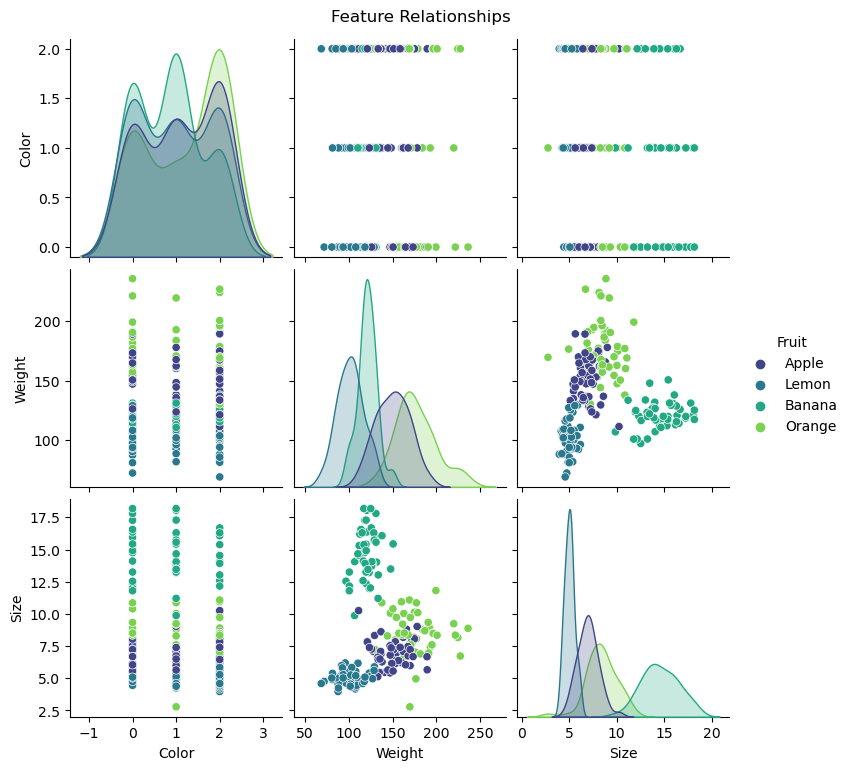

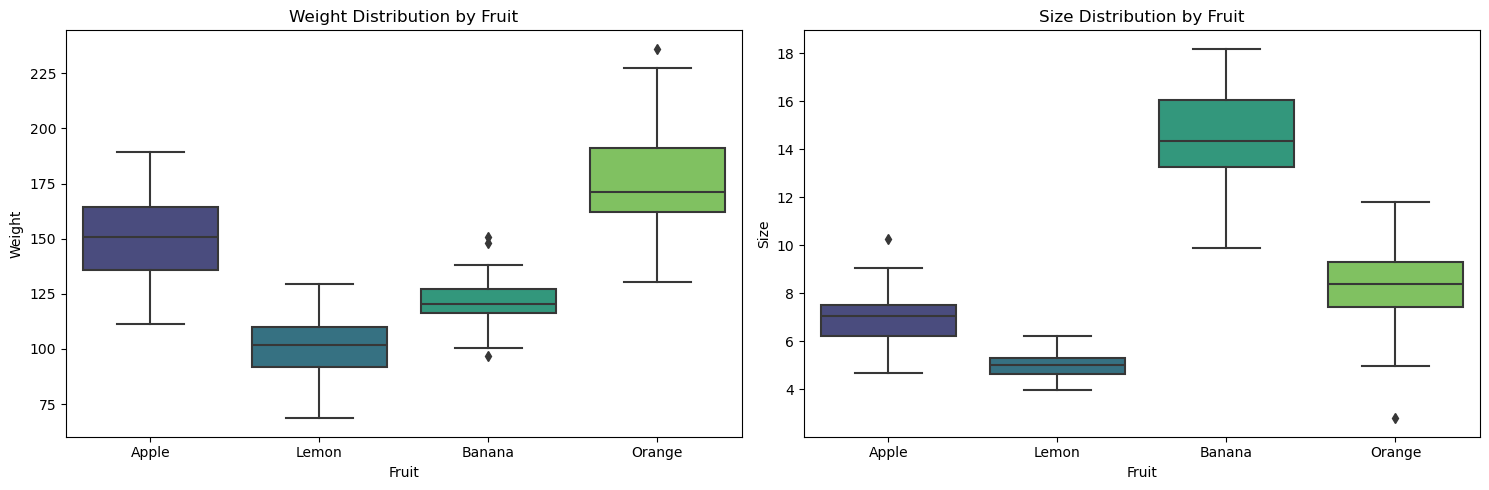

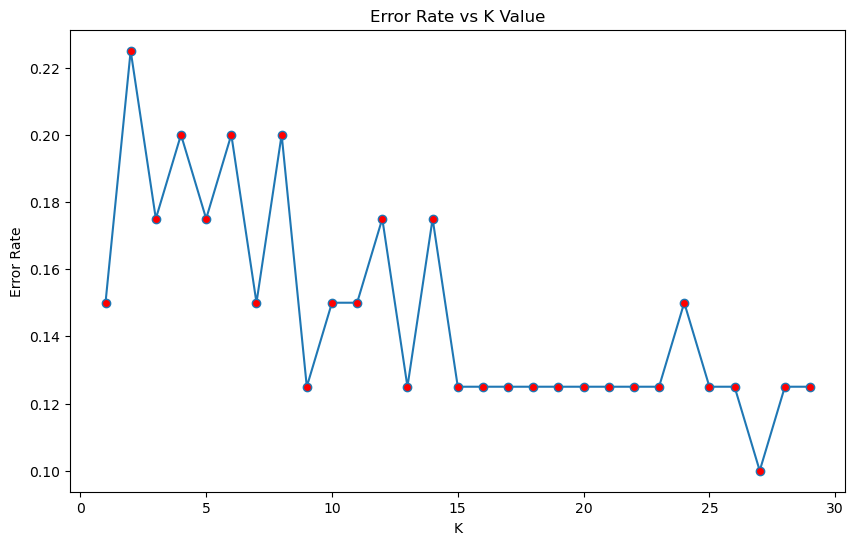

Classification Report:
              precision    recall  f1-score   support

       Apple       0.40      0.80      0.53         5
      Banana       1.00      1.00      1.00        10
       Lemon       1.00      1.00      1.00        13
      Orange       0.86      0.50      0.63        12

    accuracy                           0.82        40
   macro avg       0.81      0.82      0.79        40
weighted avg       0.88      0.82      0.83        40


Confusion Matrix:


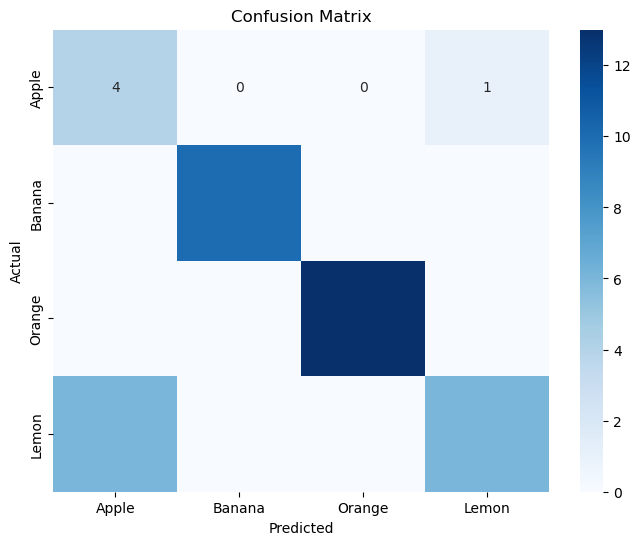

interactive(children=(IntSlider(value=0, description='Color (0-R,1-Y,2-O):', max=2), IntSlider(value=120, desc…

In [ ]:
# %% [markdown]
# # K-Nearest Neighbors (KNN) with Fruit Dataset
#
# Let's create a fruit classification system using KNN!

# %%
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from ipywidgets import interact, IntSlider

# Set random seed for reproducibility
np.random.seed(42)

# %% [markdown]
# ## 1. Create Synthetic Fruit Dataset

# %%
# Create synthetic fruit data
fruits = ['Apple', 'Banana', 'Orange', 'Lemon']
num_samples = 200

# Generate features: color (0-red, 1-yellow, 2-orange), weight (grams), size (cm)
data = {
    'Color': np.random.choice([0, 1, 2], num_samples),
    'Weight': np.concatenate([
        np.random.normal(150, 20, 50),    # Apples
        np.random.normal(120, 10, 50),    # Bananas
        np.random.normal(180, 25, 50),    # Oranges
        np.random.normal(100, 15, 50)     # Lemons
    ]),
    'Size': np.concatenate([
        np.random.normal(7, 1, 50),       # Apples
        np.random.normal(15, 2, 50),      # Bananas
        np.random.normal(8, 1.5, 50),     # Oranges
        np.random.normal(5, 0.5, 50)      # Lemons
    ]),
    'Fruit': ['Apple']*50 + ['Banana']*50 + ['Orange']*50 + ['Lemon']*50
}

df = pd.DataFrame(data)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle the dataset

# %%
# Display first 5 rows
df.head()

# %% [markdown]
# ## 2. Data Visualization

# %%
# Pairplot visualization
sns.pairplot(df, hue='Fruit', palette='viridis')
plt.suptitle('Feature Relationships', y=1.02)
plt.show()

# %%
# Feature distribution plots
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Fruit', y='Weight', data=df, palette='viridis')
plt.title('Weight Distribution by Fruit')

plt.subplot(1, 2, 2)
sns.boxplot(x='Fruit', y='Size', data=df, palette='viridis')
plt.title('Size Distribution by Fruit')

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Data Preprocessing

# %%
# Convert categorical features and split data
X = df[['Color', 'Weight', 'Size']]
y = df['Fruit']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# %% [markdown]
# ## 4. KNN Classification Model

# %%
# Find optimal k value
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rates.append(np.mean(pred != y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1,30), error_rates, marker='o', markerfacecolor='red')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# %%
# Final model with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
predictions = knn.predict(X_test_scaled)

# %%
# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=fruits, yticklabels=fruits)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# %% [markdown]
# ## 5. Interactive Prediction

# %%
# Interactive prediction function
def predict_fruit(color=0, weight=120, size=10):
    scaled_input = scaler.transform([[color, weight, size]])
    prediction = knn.predict(scaled_input)[0]
    probability = np.max(knn.predict_proba(scaled_input))

    print(f"Predicted Fruit: {prediction}")
    print(f"Confidence: {probability:.2%}")
    print("\nFeature Values:")
    print(f"Color: {['Red', 'Yellow', 'Orange'][color]}")
    print(f"Weight: {weight}g")
    print(f"Size: {size}cm")

# Create interactive widgets
interact(predict_fruit,
         color=IntSlider(value=0, min=0, max=2, step=1, description='Color (0-R,1-Y,2-O):'),
         weight=IntSlider(value=120, min=50, max=250, step=10, description='Weight (g):'),
         size=IntSlider(value=10, min=3, max=20, step=1, description='Size (cm):'));

In [ ]:

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from ipywidgets import interact, IntSlider

# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
# Create synthetic fruit data
fruits = ['Apple', 'Banana', 'Orange', 'Lemon']
num_samples = 200

data = {
    'Color': np.random.choice([0, 1, 2], num_samples),
    'Weight': np.concatenate([
        np.random.normal(150, 20, 50),    # Apples
        np.random.normal(120, 10, 50),    # Bananas
        np.random.normal(180, 25, 50),    # Oranges
        np.random.normal(100, 15, 50)     # Lemons
    ]),
    'Size': np.concatenate([
        np.random.normal(7, 1, 50),       # Apples
        np.random.normal(15, 2, 50),      # Bananas
        np.random.normal(8, 1.5, 50),     # Oranges
        np.random.normal(5, 0.5, 50)      # Lemons
    ]),
    'Fruit': ['Apple']*50 + ['Banana']*50 + ['Orange']*50 + ['Lemon']*50
}

df = pd.DataFrame(data)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle the dataset

# Display first 5 rows
df.head()

,Color,Weight,Size,Fruit
0,2,152.379570,6.648463,Apple
1,2,87.770936,3.968737,Lemon
2,0,153.373188,6.157265,Apple
3,0,123.363988,11.970850,Banana
4,2,129.445783,8.326504,Apple


/home/ck/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ck/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/ck/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


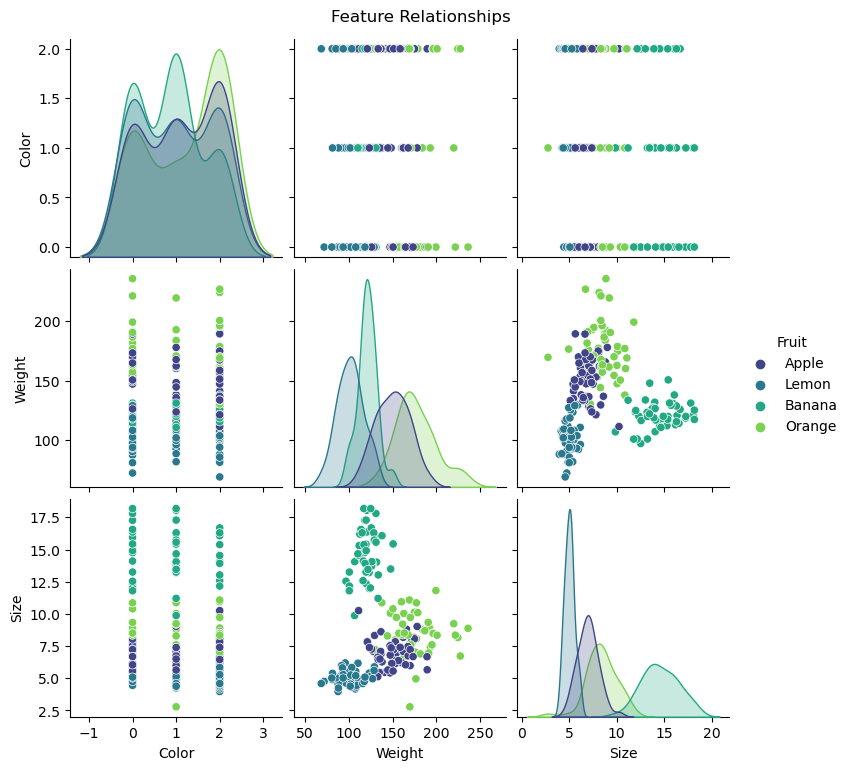

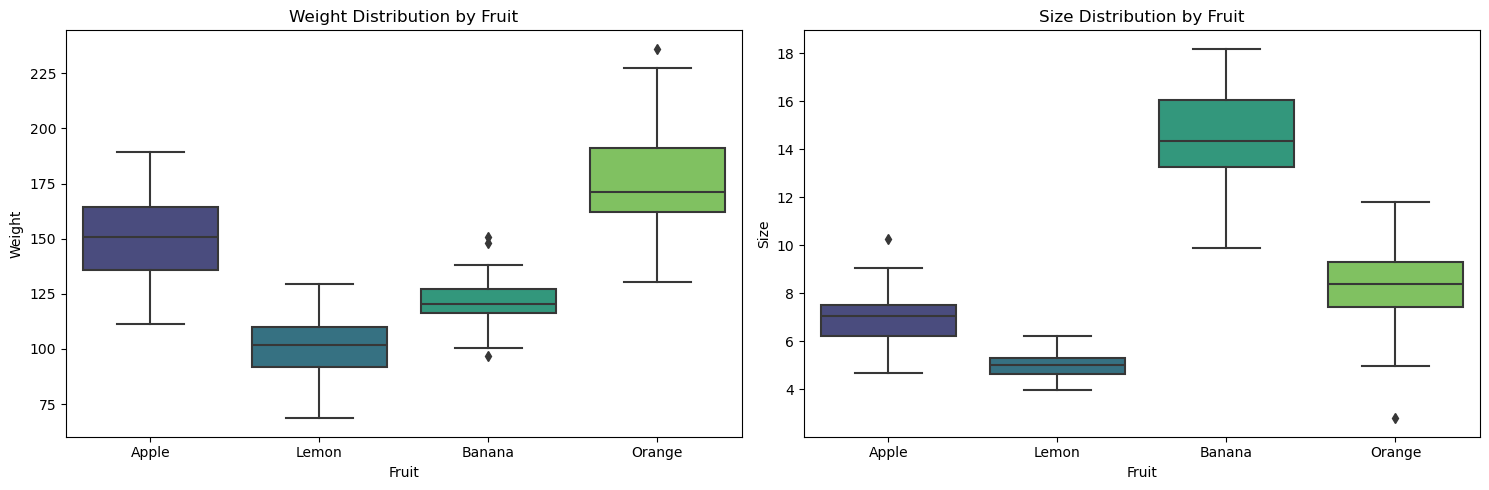

In [ ]:
# Pairplot visualization
sns.pairplot(df, hue='Fruit', palette='viridis')
plt.suptitle('Feature Relationships', y=1.02)
plt.show()

# Feature distribution plots
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Fruit', y='Weight', data=df, palette='viridis')
plt.title('Weight Distribution by Fruit')

plt.subplot(1, 2, 2)
sns.boxplot(x='Fruit', y='Size', data=df, palette='viridis')
plt.title('Size Distribution by Fruit')

plt.tight_layout()
plt.show()

In [ ]:
# Convert categorical features and split data
X = df[['Color', 'Weight', 'Size']]
y = df['Fruit']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

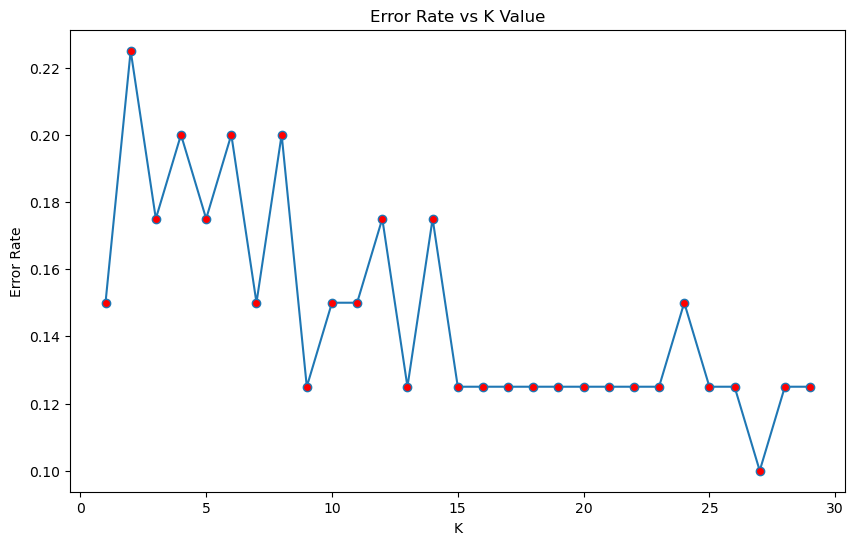

In [ ]:
# Find optimal k value
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rates.append(np.mean(pred != y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1,30), error_rates, marker='o', markerfacecolor='red')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

Classification Report:
              precision    recall  f1-score   support

       Apple       0.40      0.80      0.53         5
      Banana       1.00      1.00      1.00        10
       Lemon       1.00      1.00      1.00        13
      Orange       0.86      0.50      0.63        12

    accuracy                           0.82        40
   macro avg       0.81      0.82      0.79        40
weighted avg       0.88      0.82      0.83        40


Confusion Matrix:


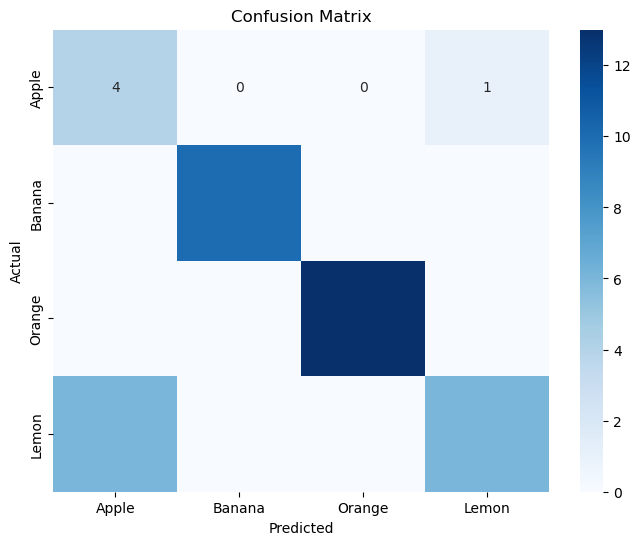

In [ ]:
# Final model with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
predictions = knn.predict(X_test_scaled)

# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=fruits, yticklabels=fruits)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Interactive prediction function
def predict_fruit(color=0, weight=120, size=10):
    scaled_input = scaler.transform([[color, weight, size]])
    prediction = knn.predict(scaled_input)[0]
    probability = np.max(knn.predict_proba(scaled_input))

    print(f"Predicted Fruit: {prediction}")
    print(f"Confidence: {probability:.2%}")
    print("\nFeature Values:")
    print(f"Color: {['Red', 'Yellow', 'Orange'][color]}")
    print(f"Weight: {weight}g")
    print(f"Size: {size}cm")

# Create interactive widgets
interact(predict_fruit,
         color=IntSlider(value=0, min=0, max=2, step=1, description='Color (0-R,1-Y,2-O):'),
         weight=IntSlider(value=120, min=50, max=250, step=10, description='Weight (g):'),
         size=IntSlider(value=10, min=3, max=20, step=1, description='Size (cm):'));

interactive(children=(IntSlider(value=0, description='Color (0-R,1-Y,2-O):', max=2), IntSlider(value=120, desc…